<a href="https://colab.research.google.com/github/Afreen-1517/RETAIL-SALES-ANALYTICS-PROJECT-/blob/main/Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==========================
# 1. IMPORT LIBRARIES
# ==========================
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# 2. LOAD DATASET
# ==========================
df = pd.read_csv('/content/Sample - Superstore.csv',encoding='latin1')

# ==========================
# 3. BASIC DATA CHECK
# ==========================
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

# ==========================
# 4. MISSING VALUES CHECK
# ==========================
print(df.isnull().sum())

# ==========================
# 5. REMOVE DUPLICATES
# ==========================
df = df.drop_duplicates()

# ==========================
# 6. DATE CONVERSION
# ==========================
df['Order Date'] = pd.to_datetime(df['Order Date'])
# ==========================
# CREATE TIME FEATURES (IMPORTANT FOR DASHBOARD)
# ==========================

df['Month Name'] = df['Order Date'].dt.strftime('%B')


# 7. SAVE CLEANED DATASET
# ==========================
df.to_csv('cleaned_superstore.csv', index=False)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [10]:
# ==========================
# 8. BASIC ANALYSIS
# ==========================

# Total Sales
print("\nTotal Sales:", df['Sales'].sum())

# Total Profit
print("Total Profit:", df['Profit'].sum())

# Sales by Category
print("\nSales by Category:")
print(df.groupby('Category')['Sales'].sum())

# Profit by Category
print("\nProfit by Category:")
print(df.groupby('Category')['Profit'].sum())

# Sales by Region
print("\nSales by Region:")
print(df.groupby('Region')['Sales'].sum())

# Profit by Region
print("\nProfit by Region:")
print(df.groupby('Region')['Profit'].sum())


Total Sales: 2297200.8603000003
Total Profit: 286397.0217

Sales by Category:
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

Profit by Category:
Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

Sales by Region:
Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Profit by Region:
Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64



Monthly Sales:
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


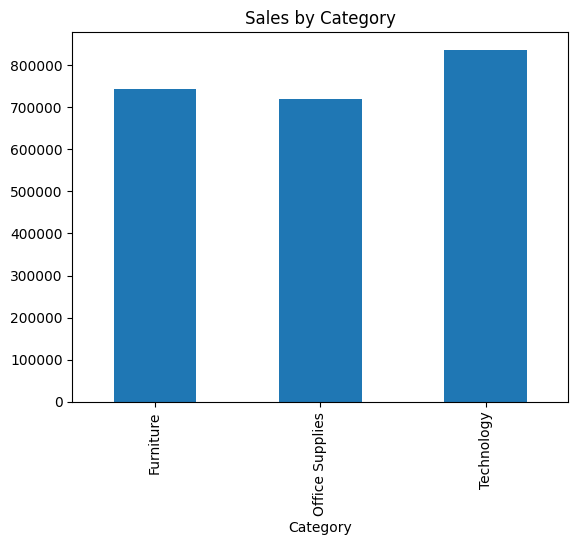

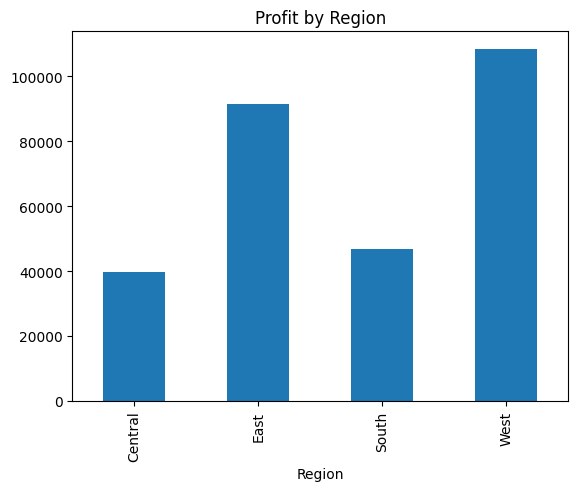

In [11]:
# ==========================
# 9. MONTHLY SALES TREND
# ==========================
df['Month'] = df['Order Date'].dt.month
print("\nMonthly Sales:")
print(df.groupby('Month')['Sales'].sum())

# ==========================
# 10. VISUALIZATIONS
# ==========================

# Sales by Category
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.show()

# Profit by Region
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.show()

In [12]:
# ==========================
# 11. BUSINESS IMPACT ANALYSIS
# ==========================

# Top 5 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Products:\n", top_products)

# Bottom 5 Products
low_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=True).head(5)
print("\nLow 5 Products:\n", low_products)

# Revenue from Top Products
top_sales_total = top_products.sum()
print("\nTop Products Revenue:", top_sales_total)

# Growth Opportunity (5%)
growth = top_sales_total * 0.05
print("Estimated Growth (5%):", growth)


Top 5 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Low 5 Products:
 Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Name: Sales, dtype: float64

Top Products Revenue: 153385.743
Estimated Growth (5%): 7669.28715

In [ ]:
#Business Insights from Superstore Analysis


#Technology category generates the highest sales, indicating strong demand in this segment.
#Tables, Bookcases, and some furniture items show low performance and may need pricing or marketing improvements.
#West region contributes the highest profit, showing strong market performance compared to other regions.
#Monthly sales trend shows fluctuations, with higher sales in specific months indicating seasonal demand.
#A small number of top products contribute a major share of revenue, confirming the 80/20 rule (Pareto principle).
#A 5% improvement in top-performing products can significantly increase overall revenue.